In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

In [4]:
!pip install torchvision

In [5]:
import torchvision
from torchvision import datasets
from torchvision import models
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms

print(f"Pytorch version: {torch.__version__}\ntorchvision version:{torchvision.__version__}")


Pytorch version: 2.11.0+cpu
torchvision version:0.26.0+cpu


In [6]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    transform=transforms.ToTensor(),
    download=True,
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.59MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]


In [12]:
image, label = train_data[0]
print(f"image dim: {image.ndim}")
print(f"label: {label}")

image dim: 3
label: 9


In [13]:
image.shape

torch.Size([1, 28, 28])

In [14]:
# colour, height and width

In [15]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [16]:
class_names = train_data.classes

In [17]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

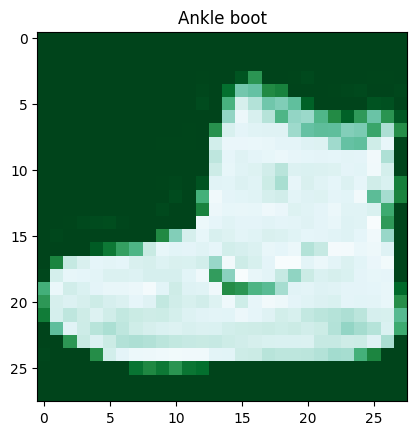

In [21]:
plt.imshow(image.squeeze(),cmap='BuGn_r')
plt.title(class_names[label])
plt.show()

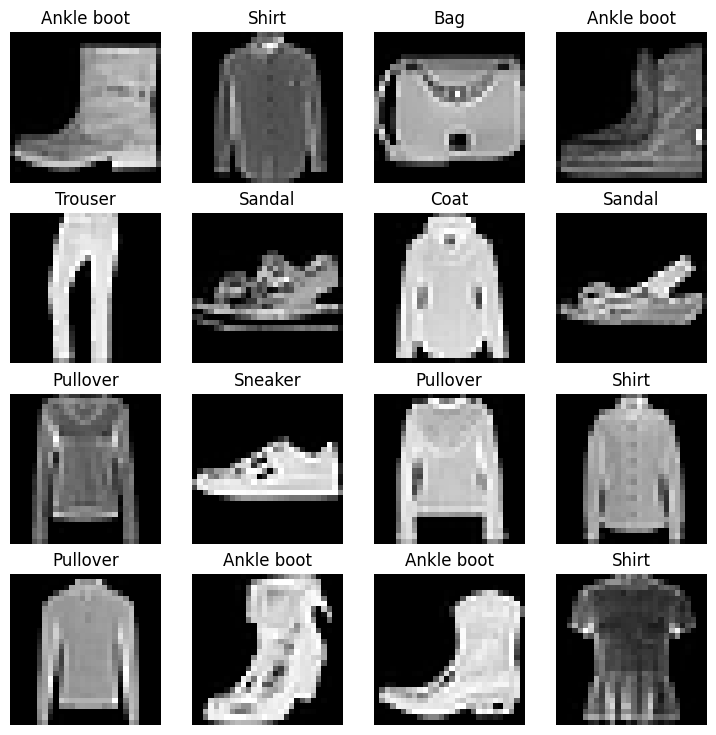

In [23]:
torch.manual_seed(42)

figure = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  image, label = train_data[random_idx]
  figure.add_subplot(rows,cols,i)
  plt.imshow(image.squeeze(),cmap="gray")
  plt.title(class_names[label])


In [24]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

print(f"DataLoaders: {train_dataloader,test_dataloader}")
print(f"length of train_dataloader: {len(train_dataloader)} batches of : {BATCH_SIZE}")
print(f"length of test_dataloader: {len(test_dataloader)} batches of : {BATCH_SIZE}")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7d6a9053bfe0>, <torch.utils.data.dataloader.DataLoader object at 0x7d6a9425f950>)
length of train_dataloader: 1875 batches of : 32
length of test_dataloader: 313 batches of : 32


In [26]:
train_features_batch, train_features_label = next(iter(train_dataloader))
test_features_batch, test_features_label = next(iter(test_dataloader))
print(train_features_batch.shape, train_features_label.shape)

torch.Size([32, 1, 28, 28]) torch.Size([32])


In [28]:
flatten_model = nn.Flatten()

x = train_features_batch[0]

output = flatten_model(x)

print(f"Shape before flattening: {x.shape} -> [colour_channels,height,width]")
print(f"Shape after flattening: {output.shape} -> [colour_channels,height*width]")

print(x)
print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [colour_channels,height,width]
Shape after flattening: torch.Size([1, 784]) -> [colour_channels,height*width]
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0

In [31]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=output_shape))

  def forward(self,x):
    return self.layer_stack(x)


model_0 = FashionMNISTModelV0(input_shape = 784,output_shape=len(class_names),hidden_units = 10)
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0330, -0.0238,  0.0294,  ...,  0.0195, -0.0210,  0.0300],
                      [-0.0145,  0.0286,  0.0324,  ...,  0.0297,  0.0300,  0.0059],
                      [-0.0343, -0.0305,  0.0264,  ..., -0.0035, -0.0163, -0.0080],
                      ...,
                      [ 0.0190, -0.0183, -0.0244,  ...,  0.0003,  0.0092, -0.0110],
                      [ 0.0201,  0.0348, -0.0352,  ...,  0.0076, -0.0161, -0.0216],
                      [-0.0254,  0.0320, -0.0231,  ...,  0.0104,  0.0163,  0.0282]])),
             ('layer_stack.1.bias',
              tensor([-0.0243, -0.0329, -0.0140,  0.0030, -0.0282, -0.0088, -0.0261, -0.0270,
                       0.0108,  0.0174])),
             ('layer_stack.2.weight',
              tensor([[ 0.0426,  0.2194, -0.0758,  0.0409,  0.2332,  0.2619,  0.0905, -0.2700,
                        0.0765,  0.2279],
                      [ 0.1077, -0.3115, -0.1033, -0.1620, -0.2846, -0.2631,  0.

In [34]:
model_0.to('cpu')

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [35]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [36]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                             lr=0.1)

In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [46]:
from tqdm.auto import tqdm

torch.random.manual_seed(42)

epochs = 4

for epoch in tqdm(range(epochs)):
  train_loss = 0

  for batch, (X,y) in enumerate(train_dataloader):

    X.to(device), y.to(device)

    model_0.train()

    train_pred = model_0(X)
    loss = loss_fn(train_pred,y)
    train_loss += loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # one full iteration through the samples

  train_loss/=len(train_dataloader)

  model_0.eval()
  test_loss,test_acc = 0,0
  with torch.inference_mode():
        for X,y in test_dataloader:
          X.to(device), y.to(device)
          test_pred = model_0(X)
          test_loss += loss_fn(test_pred,y)
          test_acc += accuracy_fn(y_true = y,
                                  y_pred=test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
  print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")


  0%|          | 0/4 [00:00<?, ?it/s]


Train loss: 0.42373 | Test loss: 0.45512, Test acc: 83.97%


Train loss: 0.41844 | Test loss: 0.48923, Test acc: 83.14%


Train loss: 0.41653 | Test loss: 0.50989, Test acc: 82.96%


Train loss: 0.41488 | Test loss: 0.45881, Test acc: 83.56%



In [55]:
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):


    model.eval()
    with torch.inference_mode():
      eval_loss, eval_acc = 0, 0
      for X,y in data_loader:
          X.to(device), y.to(device)
          pred = model(X)

          # error between predicted probabilties and actual labels
          eval_loss += loss_fn(pred,y)
          # how much do predicted labels match the actual ones
          eval_acc += accuracy_fn(y_true= y,
                            y_pred=pred.argmax(dim=1))

      eval_loss /= len(data_loader)
      eval_acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": eval_loss.item(),
            "model_acc": eval_acc}

In [56]:
model_0_results = eval_model(model=model_0,
           data_loader = test_dataloader,
           loss_fn = loss_fn,
           accuracy_fn= accuracy_fn)

In [57]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.46037736535072327,
 'model_acc': 83.52635782747603}

In [59]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
      super().__init__()
      self.layer_stack = nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features=input_shape,out_features=hidden_units),
          nn.ReLU(),
          nn.Linear(in_features=hidden_units,out_features=output_shape),
          nn.ReLU()
      )

    def forward(self, x):
      return self.layer_stack(x)

In [60]:
model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape = len(class_names)).to(device)


In [62]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.1)

In [69]:
def train_step(dataloader:torch.utils.data.DataLoader,
               model: torch.nn.Module,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):

  train_loss = 0
  train_acc = 0
  model.to(device)

  for batch, (X,y) in enumerate(dataloader):

    X.to(device), y.to(device)
    train_pred = model(X)
    loss = loss_fn(train_pred,y)
    acc = accuracy_fn(y_true=y,
                      y_pred=train_pred.argmax(dim=1))
    train_acc += acc
    train_loss += loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  # one full iteration through the samples
  train_acc/=len(dataloader)
  train_loss/=len(dataloader)

  print(f"\nTrain loss: {train_loss:.5f} | Train accuracy: {train_acc:.5f}")


def test_step(dataloader:torch.utils.data.DataLoader,
               model: torch.nn.Module,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):

  test_loss = 0
  test_acc = 0

  model.eval()
  model.to(device)

  for X,y in dataloader:

    X.to(device), y.to(device)


    test_pred = model(X)
    loss = loss_fn(train_pred,y)
    acc = accuracy_fn(y_true=y,
                      y_pred=test_pred.argmax(dim=1))
    test_acc += acc
    test_loss += loss

  # one full iteration through the samples
  test_acc/=len(dataloader)
  test_loss/=len(dataloader)

  print(f"\nTest loss: {test_loss:.5f} | Test accuracy: {test_acc:.5f}")


In [70]:
torch.manual_seed(42)

epochs = 4

for epoch in range(epochs):
   print(f"Epoch: {epoch}\n---------")
   train_step(train_dataloader,
               FashionMNISTModelV1,
               loss_fn,
               optimizer,
               accuracy_fn,
               device)

   test_step(test_dataloader,
               FashionMNISTModelV1,
               loss_fn,
               accuracy_fn,
               device)


Epoch: 0
---------


AttributeError: 'str' object has no attribute '_apply'